# 1. Load the clean data

In [149]:
import numpy as np
import pandas as pd
data_clean=pd.read_csv("cleaned_dataset.csv")
data_clean

,ViewYN,ClosePrice,Latitude,Longitude,LivingArea,CountyOrParish,ParkingTotal,PropertySubType,LotSizeAcres,YearBuilt,...,BedroomsTotal,StateOrProvince,FireplaceYN,LotSizeArea,PostalCode,LotSizeSquareFeet,date_ym,PropertyType_Residential,PropertyType_ResidentialIncome,PropertyType_ResidentialLease
0,2,1998000.0,37.871927,-122.029871,10080.0,Contra Costa,3.0,16,0.2314,1968.0,...,4.0,CA,1,10080.0,94596,10080.0,2025-12-01,True,False,False
1,1,2214421.0,34.150680,-118.580650,34745.0,Los Angeles,7.0,16,0.7976,1957.0,...,4.0,CA,1,34745.0,91364,34745.0,2025-12-01,True,False,False
2,0,1200000.0,37.306405,-121.835428,6600.0,Santa Clara,2.0,16,0.1515,1978.0,...,4.0,CA,1,6600.0,95121,6600.0,2025-12-01,True,False,False
3,1,3300.0,34.023768,-117.421341,17500.0,Riverside,2.0,16,0.4017,1977.0,...,4.0,CA,1,17500.0,92509,17500.0,2025-12-01,False,False,True
4,0,3100000.0,37.272636,-121.921351,8262.0,Santa Clara,1.0,16,0.1897,2025.0,...,5.0,CA,0,8262.0,95124,8262.0,2025-12-01,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102368,2,21500000.0,37.854648,-121.961587,935669.0,Contra Costa,24.0,16,21.4800,2010.0,...,10.0,CA,1,935669.0,94507,935669.0,2026-05-01,True,False,False
102369,1,1650.0,33.860363,-116.555055,436.0,Riverside,3.0,4,0.0100,1982.0,...,1.0,CA,0,436.0,92262,436.0,2026-05-01,False,False,True
102370,0,400000.0,34.167919,-118.524791,30457.0,Los Angeles,3.0,4,0.6992,1964.0,...,2.0,CA,0,30457.0,91316,30457.0,2026-05-01,True,False,False
102371,1,6950.0,33.492283,-117.712305,5760.0,Orange,2.0,16,0.1322,1987.0,...,4.0,CA,1,5760.0,92677,5760.0,2026-05-01,False,False,True


# 2. Test train valid split

In [150]:
X=6 # past 2 month
months = sorted(data_clean["date_ym"].unique())
# data_train=data_clean[data_clean['date_ym'].isin(months[-X:-2])]
# data_valid=data_clean[data_clean['date_ym'].isin(months[-2:-1])]
# data_test=data_clean[data_clean['date_ym']==months[-1]]
data_train=data_clean[data_clean['date_ym'].isin(months[-X:-1])]
data_test=data_clean[data_clean['date_ym']==months[-1]]
print(data_train['date_ym'].value_counts())
print(data_test['date_ym'].value_counts())
data_train.info()

date_ym
2026-04-01    19418
2026-03-01    18681
2025-12-01    16541
2026-02-01    14772
2026-01-01    13472
Name: count, dtype: int64
date_ym
2026-05-01    19489
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 82884 entries, 0 to 82883
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ViewYN                          82884 non-null  int64  
 1   ClosePrice                      82884 non-null  float64
 2   Latitude                        82884 non-null  float64
 3   Longitude                       82884 non-null  float64
 4   LivingArea                      82884 non-null  float64
 5   CountyOrParish                  82884 non-null  object 
 6   ParkingTotal                    82884 non-null  float64
 7   PropertySubType                 82884 non-null  int64  
 8   LotSizeAcres                    82884 non-null  float64
 9   YearBuilt                       

In [151]:
cols=["CountyOrParish","City","StateOrProvince"]
for col in cols:
    top10 = data_train[col].value_counts().nlargest(10).index
    data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
    data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
data_train = pd.get_dummies(data_train, columns=cols, drop_first=True)
data_test = pd.get_dummies(data_test, columns=cols, drop_first=True)
# 保证列一致
data_test = data_test.reindex(columns=data_train.columns, fill_value=0)

C:\Users\23035\AppData\Local\Temp\ipykernel_71788\4071425352.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_71788\4071425352.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_71788\4071425352.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of 

In [152]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19489 entries, 82884 to 102372
Data columns (total 44 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ViewYN                          19489 non-null  int64  
 1   ClosePrice                      19489 non-null  float64
 2   Latitude                        19489 non-null  float64
 3   Longitude                       19489 non-null  float64
 4   LivingArea                      19489 non-null  float64
 5   ParkingTotal                    19489 non-null  float64
 6   PropertySubType                 19489 non-null  int64  
 7   LotSizeAcres                    19489 non-null  float64
 8   YearBuilt                       19489 non-null  float64
 9   StreetNumberNumeric             19489 non-null  float64
 10  BathroomsTotalInteger           19489 non-null  float64
 11  BedroomsTotal                   19489 non-null  float64
 12  FireplaceYN                     

In [153]:
# remove some columns that related to the feature
X_train, y_train = data_train.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object"]).columns.tolist()), data_train["ClosePrice"]
X_test, y_test = data_test.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object"]).columns.tolist()), data_test["ClosePrice"]

In [154]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 82884 entries, 0 to 82883
Data columns (total 41 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ViewYN                          82884 non-null  int64  
 1   Latitude                        82884 non-null  float64
 2   Longitude                       82884 non-null  float64
 3   LivingArea                      82884 non-null  float64
 4   ParkingTotal                    82884 non-null  float64
 5   PropertySubType                 82884 non-null  int64  
 6   LotSizeAcres                    82884 non-null  float64
 7   YearBuilt                       82884 non-null  float64
 8   StreetNumberNumeric             82884 non-null  float64
 9   BathroomsTotalInteger           82884 non-null  float64
 10  BedroomsTotal                   82884 non-null  float64
 11  FireplaceYN                     82884 non-null  int64  
 12  LotSizeArea                     82884

# 3. Train a Linear Regression model and Evaluate the result

In [155]:
results = []

## 3.1 Ordinary Linear Regression 

In [156]:
#linear regression
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

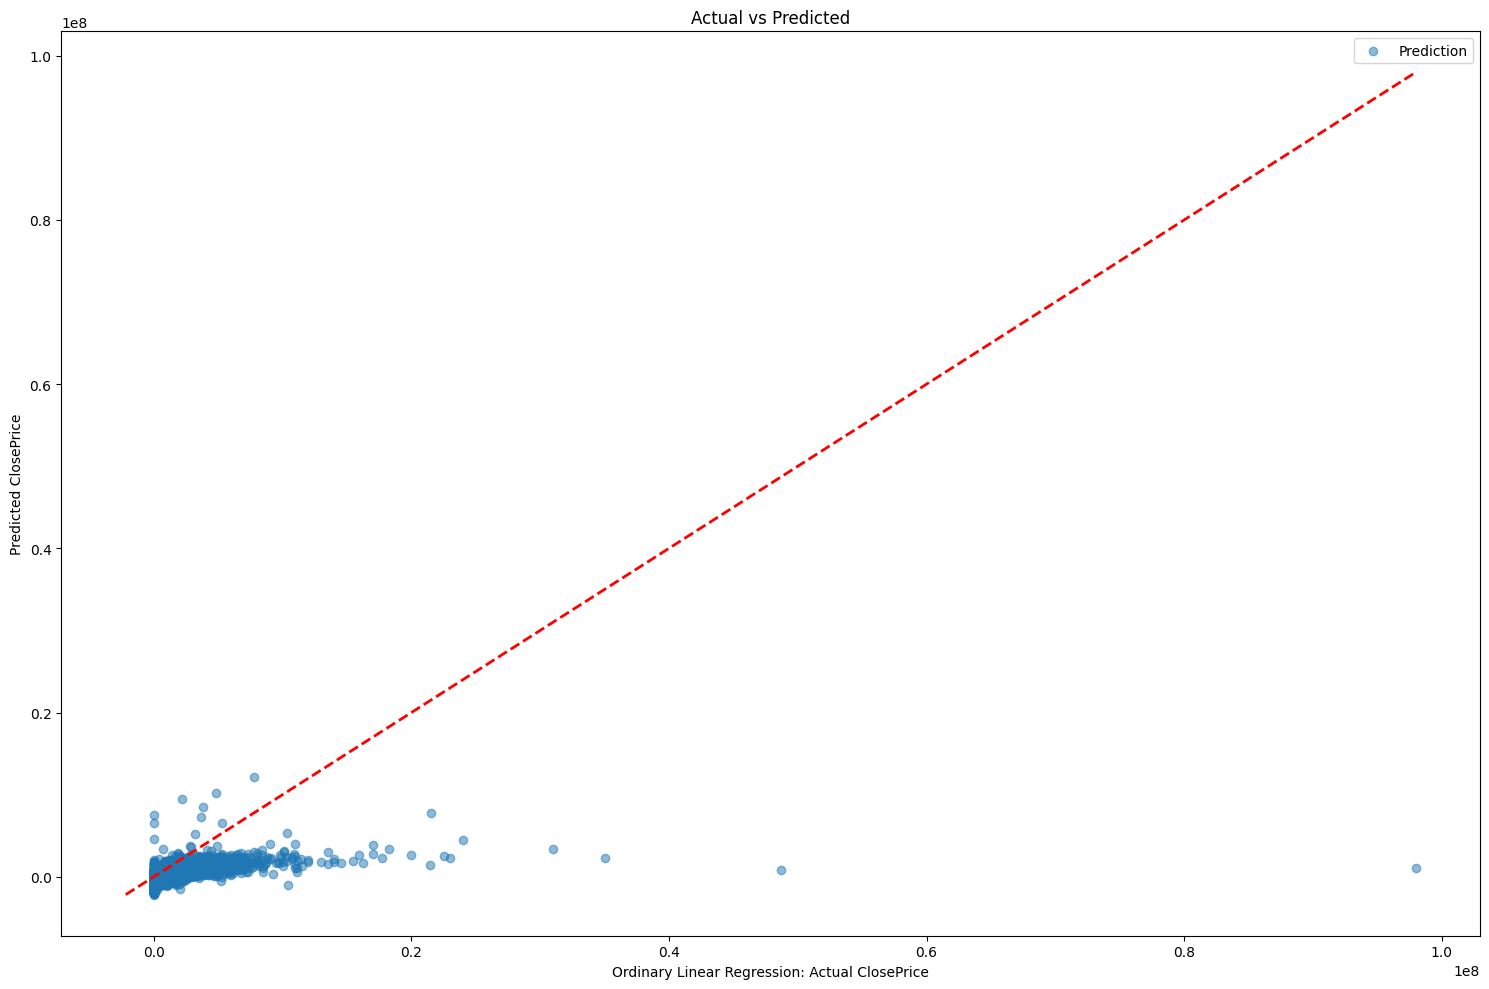

In [157]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Ordinary Linear Regression: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [158]:
# Median Absolute Percentage Error, MAPE,R2,MAE,MSE,RMSE

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

results.append({
    "model":"Ordinary Linear Regression",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

MdAPE: 88.06%
MAPE : 74.4327
R²   : -0.0497
MAE  : 878314.4226
MSE  : 2169772198897.1567
RMSE : 1473014.6635


## 3.2 Ridge Regression

In [159]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

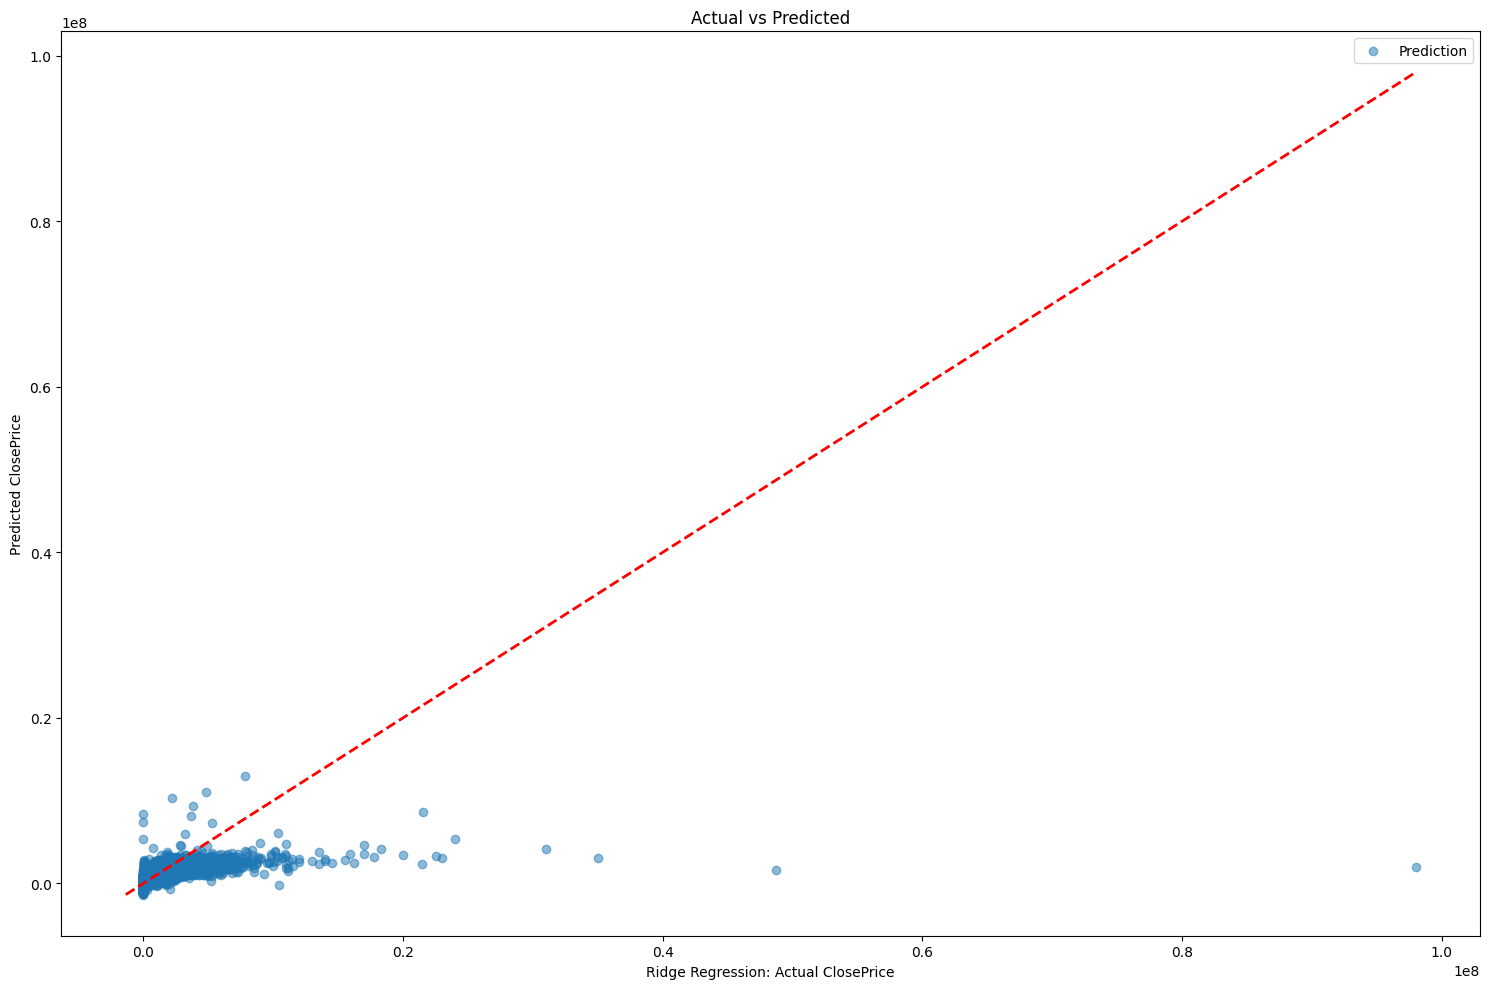

In [160]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Ridge Regression: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [161]:
# Median Absolute Percentage Error, MAPE,R2,MAE,MSE,RMSE

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

results.append({
    "model":"Ridge Regression",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

MdAPE: 52.42%
MAPE : 28.8901
R²   : 0.2936
MAE  : 490599.1755
MSE  : 1460198718200.0652
RMSE : 1208386.8247


## 3.3 Lasso Regression

In [162]:
from sklearn.linear_model import Lasso

model = Lasso(alpha=0.1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

C:\Users\23035\.conda\envs\PUBLIC_MRI\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.253e+18, tolerance: 2.563e+14
  model = cd_fast.enet_coordinate_descent(


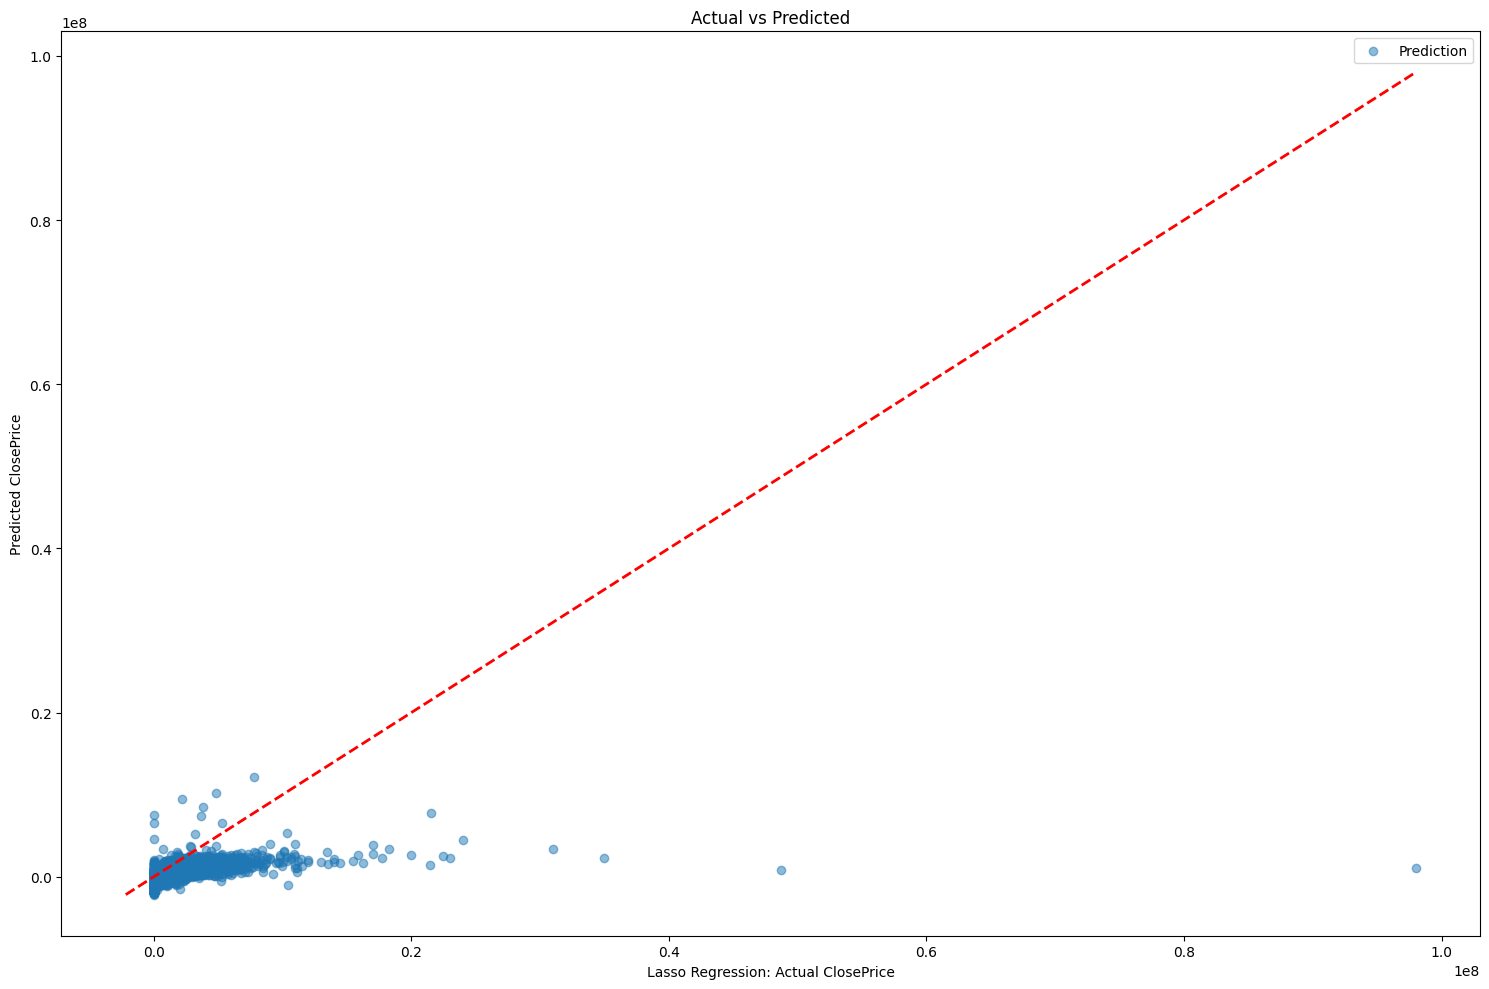

In [163]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Lasso Regression: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [164]:
# Median Absolute Percentage Error, MAPE,R2,MAE,MSE,RMSE

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

results.append({
    "model":"Lasso Regression",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

MdAPE: 86.39%
MAPE : 73.3015
R²   : -0.0363
MAE  : 863766.1061
MSE  : 2142078062904.8730
RMSE : 1463583.9788


## 3.4 ElasticNet

In [165]:
from sklearn.linear_model import ElasticNet

model = ElasticNet(alpha=0.1, l1_ratio=0.5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

C:\Users\23035\.conda\envs\PUBLIC_MRI\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.256e+18, tolerance: 2.563e+14
  model = cd_fast.enet_coordinate_descent(


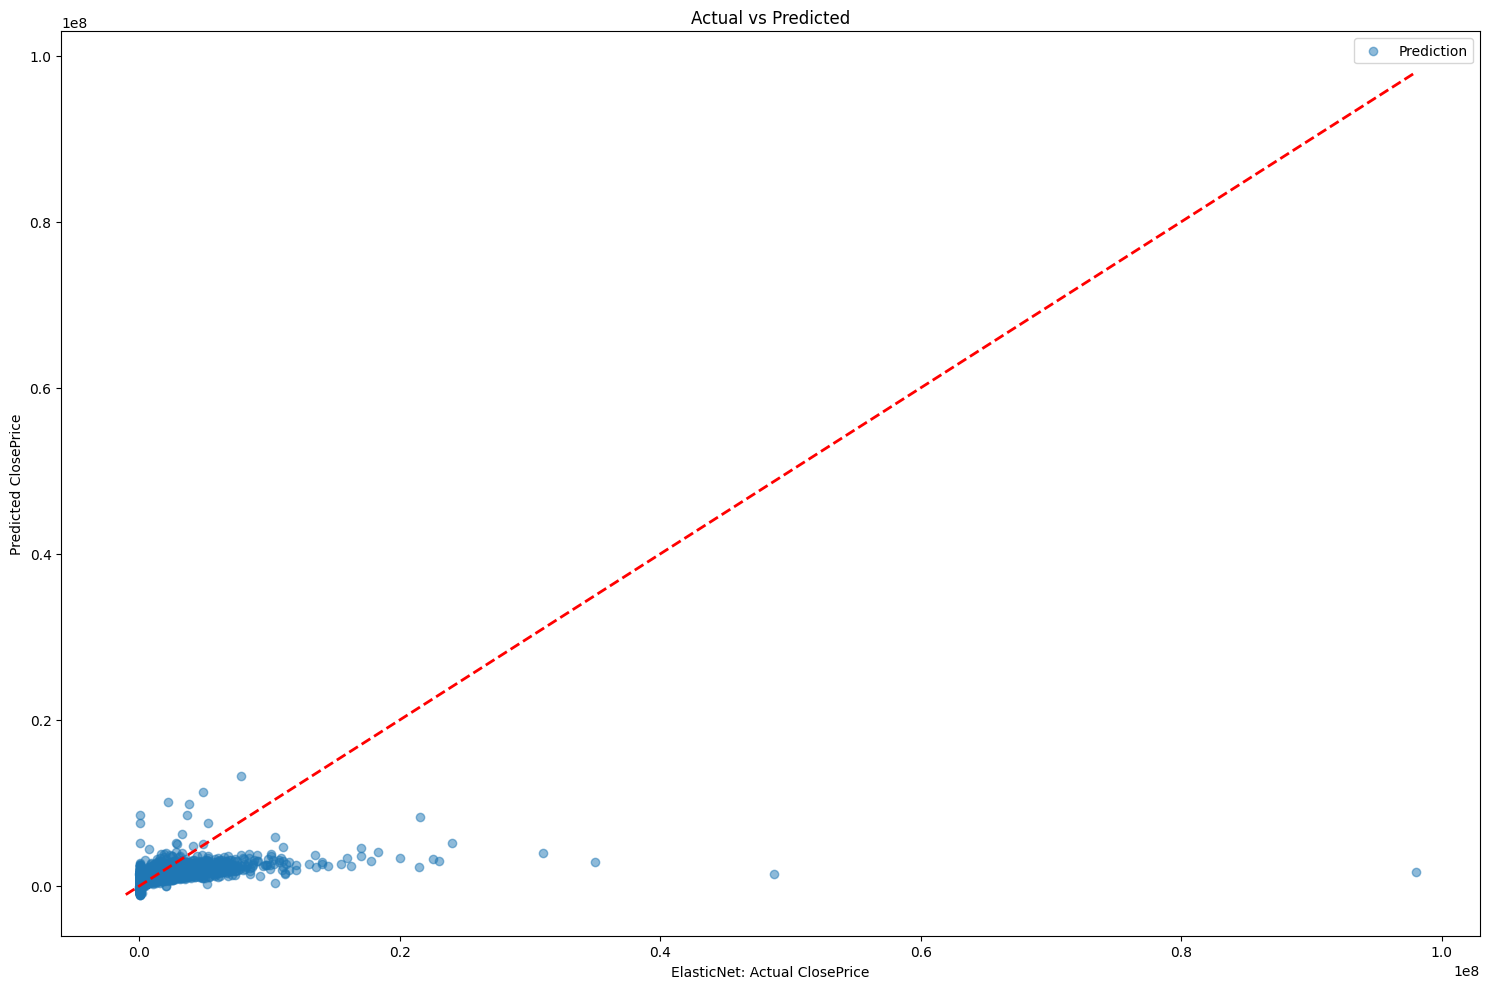

In [166]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("ElasticNet: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [167]:
# Median Absolute Percentage Error, MAPE,R2,MAE,MSE,RMSE

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

results.append({
    "model":"ElasticNet",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

MdAPE: 56.95%
MAPE : 23.0461
R²   : 0.2839
MAE  : 490474.3807
MSE  : 1480297405125.6873
RMSE : 1216674.7327


# 5. Rolling-Origin Backtesting

In [170]:
result_roll=[]

for X in [3,4,5]:
    months = sorted(data_clean["date_ym"].unique())
    data_train=data_clean[data_clean['date_ym'].isin(months[:X])]
    data_test=data_clean[data_clean['date_ym']==months[X]]
    cols=["CountyOrParish","City","StateOrProvince"]
    for col in cols:
       top10 = data_train[col].value_counts().nlargest(10).index
       data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
       data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
    data_train = pd.get_dummies(data_train, columns=cols, drop_first=True)
    data_test = pd.get_dummies(data_test, columns=cols, drop_first=True)
    # 保证列一致
    data_test = data_test.reindex(columns=data_train.columns, fill_value=0)
    X_train, y_train = data_train.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object"]).columns.tolist()), data_train["ClosePrice"]
    X_test, y_test = data_test.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object"]).columns.tolist()), data_test["ClosePrice"]

    # linear regression
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print(f"------------------------------{X}----------------------------------")
    print("--------------Ordinary Linear regression-------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll.append({
    "model":"Ordinary Linear Regression",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })

    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print("--------------Ridge regression-------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll.append({
    "model":"Ridge Regression",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })
    
    model = Lasso(alpha=0.1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print("--------------Lasso regression-------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll.append({
    "model":"Lasso Regression",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })

    model = ElasticNet(alpha=0.1, l1_ratio=0.5)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print("--------------ElasticNet regression-------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll.append({
    "model":"ElasticNet",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })

    

C:\Users\23035\AppData\Local\Temp\ipykernel_71788\1011119209.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_71788\1011119209.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_71788\1011119209.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy 

------------------------------3----------------------------------
--------------Ordinary Linear regression-------------
MdAPE: 60.50%
MAPE : 26.1767
R²   : 0.3611
MAE  : 491694.6527
MSE  : 1088807522419.0405
RMSE : 1043459.4014
--------------Ridge regression-------------
MdAPE: 60.51%
MAPE : 26.1737
R²   : 0.3611
MAE  : 491697.3476
MSE  : 1088800601895.6514
RMSE : 1043456.0853


C:\Users\23035\.conda\envs\PUBLIC_MRI\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.102e+17, tolerance: 1.449e+14
  model = cd_fast.enet_coordinate_descent(


--------------Lasso regression-------------
MdAPE: 60.50%
MAPE : 26.1767
R²   : 0.3611
MAE  : 491694.6673
MSE  : 1088807256025.2593
RMSE : 1043459.2738


C:\Users\23035\.conda\envs\PUBLIC_MRI\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.121e+17, tolerance: 1.449e+14
  model = cd_fast.enet_coordinate_descent(
C:\Users\23035\AppData\Local\Temp\ipykernel_71788\1011119209.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_71788\1011119209.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer]

...

C:\Users\23035\.conda\envs\PUBLIC_MRI\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.226e+17, tolerance: 1.481e+14
  model = cd_fast.enet_coordinate_descent(
C:\Users\23035\AppData\Local\Temp\ipykernel_71788\1011119209.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_71788\1011119209.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer]

--------------ElasticNet regression-------------
MdAPE: 54.63%
MAPE : 22.0217
R²   : 0.0141
MAE  : 558375.4157
MSE  : 54935684863826.7812
RMSE : 7411861.0931
------------------------------5----------------------------------
--------------Ordinary Linear regression-------------
MdAPE: 88.06%
MAPE : 74.4327
R²   : -0.0497
MAE  : 878314.4226
MSE  : 2169772198897.1567
RMSE : 1473014.6635
--------------Ridge regression-------------
MdAPE: 52.42%
MAPE : 28.8901
R²   : 0.2936
MAE  : 490599.1755
MSE  : 1460198718200.0652
RMSE : 1208386.8247


C:\Users\23035\.conda\envs\PUBLIC_MRI\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.253e+18, tolerance: 2.563e+14
  model = cd_fast.enet_coordinate_descent(


--------------Lasso regression-------------
MdAPE: 86.39%
MAPE : 73.3015
R²   : -0.0363
MAE  : 863766.1061
MSE  : 2142078062904.8730
RMSE : 1463583.9788
--------------ElasticNet regression-------------
MdAPE: 56.95%
MAPE : 23.0461
R²   : 0.2839
MAE  : 490474.3807
MSE  : 1480297405125.6873
RMSE : 1216674.7327


C:\Users\23035\.conda\envs\PUBLIC_MRI\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.256e+18, tolerance: 2.563e+14
  model = cd_fast.enet_coordinate_descent(


# 6. Record results

In [173]:
import pandas as pd

result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

result.to_csv("prediction_result.csv", index=True)
pd.DataFrame(results).to_csv("model_result.csv",index=True)
pd.DataFrame(result_roll).to_csv("model_result_roll.csv",index=True)